In [67]:
import pandas as pd
import numpy as np

In [68]:
apple_df = pd.read_csv("AppleStore.csv")

In [69]:
apple_df.head()

,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


In [70]:
apple_df.shape

(7197, 17)

In [71]:
apple_df.dtypes

Unnamed: 0            int64
id                    int64
track_name           object
size_bytes            int64
currency             object
price               float64
rating_count_tot      int64
rating_count_ver      int64
user_rating         float64
user_rating_ver     float64
ver                  object
cont_rating          object
prime_genre          object
sup_devices.num       int64
ipadSc_urls.num       int64
lang.num              int64
vpp_lic               int64
dtype: object

In [72]:
apple_df.drop('Unnamed: 0',axis=1,inplace=True)

In [73]:
apple_df['id'] = apple_df['id'].astype(str)

In [74]:
apple_df['vpp_lic'] = apple_df['vpp_lic'].astype(bool)

In [75]:
apple_df.dtypes

id                   object
track_name           object
size_bytes            int64
currency             object
price               float64
rating_count_tot      int64
rating_count_ver      int64
user_rating         float64
user_rating_ver     float64
ver                  object
cont_rating          object
prime_genre          object
sup_devices.num       int64
ipadSc_urls.num       int64
lang.num              int64
vpp_lic                bool
dtype: object

In [76]:
apple_df.isnull().sum()

id                  0
track_name          0
size_bytes          0
currency            0
price               0
rating_count_tot    0
rating_count_ver    0
user_rating         0
user_rating_ver     0
ver                 0
cont_rating         0
prime_genre         0
sup_devices.num     0
ipadSc_urls.num     0
lang.num            0
vpp_lic             0
dtype: int64

In [77]:
apple_df.duplicated().sum()

np.int64(0)

In [78]:
apple_df['prime_genre'].value_counts()

prime_genre
Games                3862
Entertainment         535
Education             453
Photo & Video         349
Utilities             248
Health & Fitness      180
Productivity          178
Social Networking     167
Lifestyle             144
Music                 138
Shopping              122
Sports                114
Book                  112
Finance               104
Travel                 81
News                   75
Weather                72
Reference              64
Food & Drink           63
Business               57
Navigation             46
Medical                23
Catalogs               10
Name: count, dtype: int64

In [79]:
apple_df['cont_rating'].value_counts()

cont_rating
4+     4433
12+    1155
9+      987
17+     622
Name: count, dtype: int64

In [80]:
apple_df['price'].value_counts()

price
0.00      4056
0.99       728
2.99       683
1.99       621
4.99       394
3.99       277
6.99       166
9.99        81
5.99        52
7.99        33
14.99       21
19.99       13
8.99         9
24.99        8
29.99        6
13.99        6
11.99        6
12.99        5
15.99        4
17.99        3
59.99        3
39.99        2
20.99        2
23.99        2
49.99        2
22.99        2
27.99        2
16.99        2
299.99       1
21.99        1
47.99        1
99.99        1
74.99        1
34.99        1
18.99        1
249.99       1
Name: count, dtype: int64

In [81]:
(apple_df['price']==0).value_counts()

price
True     4056
False    3141
Name: count, dtype: int64

In [82]:
apple_df['user_rating'].value_counts()

user_rating
4.5    2663
4.0    1626
0.0     929
3.5     702
5.0     492
3.0     383
2.5     196
2.0     106
1.5      56
1.0      44
Name: count, dtype: int64

In [83]:
def is_english(string):
    for char in string:
        if ord(char) > 127:
            return False
    return True

In [84]:
apple_df.shape

(7197, 16)

In [85]:
apple_df = apple_df[apple_df['track_name'].apply(is_english)]

In [86]:
apple_df.shape

(5707, 16)

In [87]:
# Highly rated apps
high_rated_apps = apple_df[apple_df['user_rating']>4]
high_rated_apps

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
4,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,True
8,284666222,PCalc - The Best Calculator,49250304,USD,9.99,1117,4,4.5,5.0,3.6.6,4+,Utilities,37,5,1,True
10,284791396,Solitaire by MobilityWare,49618944,USD,4.99,76720,4017,4.5,4.5,4.10.1,4+,Games,38,4,11,True
14,284862767,FreeCell,55153664,USD,4.99,6340,668,4.5,4.5,4.0.3,4+,Games,38,5,2,True
20,285946052,iQuran,70707916,USD,1.99,2929,966,4.5,4.5,3.3,4+,Reference,43,0,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7192,1187617475,Kubik,126644224,USD,0.00,142,75,4.5,4.5,1.3,4+,Games,38,5,1,True
7193,1187682390,VR Roller-Coaster,120760320,USD,0.00,30,30,4.5,4.5,0.9,4+,Games,38,0,1,True
7194,1187779532,Bret Michaels Emojis + Lyric Keyboard,111322112,USD,1.99,15,0,4.5,0.0,1.0.2,9+,Utilities,37,1,1,True
7195,1187838770,VR Roller Coaster World - Virtual Reality,97235968,USD,0.00,85,32,4.5,4.5,1.0.15,12+,Games,38,0,2,True


In [88]:
# Most Reviewed Apps
most_reviewed_apps = apple_df[apple_df['rating_count_tot']>1000000]
most_reviewed_apps

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
7,284035177,Pandora - Music & Radio,130242560,USD,0.0,1126879,3594,4.0,4.5,8.4.1,12+,Music,37,4,1,True
16,284882215,Facebook,389879808,USD,0.0,2974676,212,3.5,3.5,95,4+,Social Networking,37,1,29,True
519,389801252,Instagram,113954816,USD,0.0,2161558,1289,4.5,4.0,10.23,12+,Photo & Video,37,0,29,True
707,420009108,Temple Run,65921024,USD,0.0,1724546,3842,4.5,4.0,1.6.2,9+,Games,40,5,1,True
755,429047995,Pinterest,74778624,USD,0.0,1061624,1814,4.5,4.0,6.26,12+,Social Networking,37,5,27,True
1346,529479190,Clash of Clans,116476928,USD,0.0,2130805,579,4.5,4.5,9.24.12,9+,Games,38,5,18,True


In [89]:
# Free Apps
free_apps = apple_df[apple_df['price']==0]
free_apps

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
1,281796108,Evernote - stay organized,158578688,USD,0.0,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,True
2,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.0,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,True
3,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.0,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,True
4,282935706,Bible,92774400,USD,0.0,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,True
6,283646709,PayPal - Send and request money safely,227795968,USD,0.0,119487,879,4.0,4.5,6.12.0,4+,Finance,37,0,19,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7188,1186384912,Demolition Derby Virtual Reality (VR) Racing,168774656,USD,0.0,18,18,4.0,4.0,1.0.0,12+,Games,38,4,1,True
7192,1187617475,Kubik,126644224,USD,0.0,142,75,4.5,4.5,1.3,4+,Games,38,5,1,True
7193,1187682390,VR Roller-Coaster,120760320,USD,0.0,30,30,4.5,4.5,0.9,4+,Games,38,0,1,True
7195,1187838770,VR Roller Coaster World - Virtual Reality,97235968,USD,0.0,85,32,4.5,4.5,1.0.15,12+,Games,38,0,2,True


In [90]:
# Apps by Genre
games_app = apple_df[apple_df['prime_genre']=='Games']
games_app

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,True
5,283619399,Shanghai Mahjong,10485713,USD,0.99,8253,5516,4.0,4.0,1.8,4+,Games,47,5,1,True
9,284736660,Ms. PAC-MAN,70023168,USD,3.99,7885,40,4.0,4.0,4.0.4,4+,Games,38,0,10,True
10,284791396,Solitaire by MobilityWare,49618944,USD,4.99,76720,4017,4.5,4.5,4.10.1,4+,Games,38,4,11,True
11,284815117,SCRABBLE Premium,227547136,USD,7.99,105776,166,3.5,2.5,5.19.0,4+,Games,37,0,6,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7191,1187282363,Plead the Fifth - The Game,27853824,USD,2.99,11,0,4.0,0.0,1.1.1,17+,Games,37,0,1,True
7192,1187617475,Kubik,126644224,USD,0.00,142,75,4.5,4.5,1.3,4+,Games,38,5,1,True
7193,1187682390,VR Roller-Coaster,120760320,USD,0.00,30,30,4.5,4.5,0.9,4+,Games,38,0,1,True
7195,1187838770,VR Roller Coaster World - Virtual Reality,97235968,USD,0.00,85,32,4.5,4.5,1.0.15,12+,Games,38,0,2,True


In [91]:
# Rating > 4
# Reviews > 1000000
# Free apps

top_apps = apple_df[(apple_df['user_rating']>4) & (apple_df['rating_count_tot']>1000000) & (apple_df['price']==0)]
top_apps

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
519,389801252,Instagram,113954816,USD,0.0,2161558,1289,4.5,4.0,10.23,12+,Photo & Video,37,0,29,True
707,420009108,Temple Run,65921024,USD,0.0,1724546,3842,4.5,4.0,1.6.2,9+,Games,40,5,1,True
755,429047995,Pinterest,74778624,USD,0.0,1061624,1814,4.5,4.0,6.26,12+,Social Networking,37,5,27,True
1346,529479190,Clash of Clans,116476928,USD,0.0,2130805,579,4.5,4.5,9.24.12,9+,Games,38,5,18,True


In [92]:
# Average Rating by Genre
apple_df.groupby('prime_genre')['user_rating'].mean().sort_values(ascending=False)

prime_genre
Catalogs             4.250000
Games                4.062559
Productivity         4.055921
Music                3.981343
Health & Fitness     3.976027
Shopping             3.966216
Reference            3.936170
Business             3.930000
Book                 3.854167
Photo & Video        3.821429
Weather              3.671875
Food & Drink         3.627907
Education            3.585714
Travel               3.581633
Navigation           3.543478
Social Networking    3.536036
Entertainment        3.487562
Lifestyle            3.421348
Finance              3.420455
Medical              3.400000
News                 3.382353
Utilities            3.361979
Sports               3.086957
Name: user_rating, dtype: float64

In [93]:
# Total Reviews by Genre
apple_df.groupby('prime_genre')['rating_count_tot'].sum().sort_values(ascending=False)

prime_genre
Games                47188876
Social Networking     7157485
Photo & Video         4825630
Music                 3685852
Entertainment         3670413
Shopping              2110785
Sports                1556296
Reference             1422400
Health & Fitness      1381638
Productivity          1372475
Weather               1359727
Travel                1137728
News                   966118
Utilities              934103
Food & Drink           876802
Education              844205
Finance                843979
Lifestyle              785487
Navigation             524754
Business               219771
Book                   146490
Catalogs                16894
Medical                 12330
Name: rating_count_tot, dtype: int64

In [94]:
# Number of Apps in Each Genre
apple_df['prime_genre'].value_counts()

prime_genre
Games                3165
Entertainment         402
Education             385
Photo & Video         322
Utilities             192
Productivity          152
Health & Fitness      146
Music                 134
Social Networking     111
Sports                 92
Lifestyle              89
Shopping               74
Weather                64
News                   51
Business               50
Travel                 49
Book                   48
Reference              47
Finance                44
Food & Drink           43
Navigation             23
Medical                20
Catalogs                4
Name: count, dtype: int64

In [95]:
# Top 10 Most Reviewed Apps
apple_df.sort_values(by='rating_count_tot',ascending=False).head(10)

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
16,284882215,Facebook,389879808,USD,0.0,2974676,212,3.5,3.5,95,4+,Social Networking,37,1,29,True
519,389801252,Instagram,113954816,USD,0.0,2161558,1289,4.5,4.0,10.23,12+,Photo & Video,37,0,29,True
1346,529479190,Clash of Clans,116476928,USD,0.0,2130805,579,4.5,4.5,9.24.12,9+,Games,38,5,18,True
707,420009108,Temple Run,65921024,USD,0.0,1724546,3842,4.5,4.0,1.6.2,9+,Games,40,5,1,True
7,284035177,Pandora - Music & Radio,130242560,USD,0.0,1126879,3594,4.0,4.5,8.4.1,12+,Music,37,4,1,True
755,429047995,Pinterest,74778624,USD,0.0,1061624,1814,4.5,4.0,6.26,12+,Social Networking,37,5,27,True
4,282935706,Bible,92774400,USD,0.0,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,True
1493,553834731,Candy Crush Saga,222846976,USD,0.0,961794,2453,4.5,4.5,1.101.0,4+,Games,43,5,24,True
178,324684580,Spotify Music,132510720,USD,0.0,878563,8253,4.5,4.5,8.4.3,12+,Music,37,5,18,True
275,343200656,Angry Birds,175966208,USD,0.0,824451,107,4.5,3.0,7.4.0,4+,Games,38,0,10,True


In [96]:
# Top 10 Highest Rated Apps
apple_df.sort_values(by='user_rating',ascending=False).head(10)

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
7196,1188375727,Escape the Sweet Shop Series,90898432,USD,0.00,3,3,5.0,5.0,1,4+,Games,40,0,2,True
5484,1085908608,Able Black,312574976,USD,1.99,876,812,5.0,5.0,3,12+,Games,40,5,1,True
5543,1087489471,War Tortoise,407088128,USD,0.00,10555,1026,5.0,5.0,1.2.1,12+,Games,40,5,1,True
5541,1087422283,Akuarella,99978240,USD,1.99,7,7,5.0,5.0,1.2.1,17+,Photo & Video,37,4,2,True
3271,949838009,Dreamdays: Count Down to the Days that Matter,52049920,USD,0.99,7863,99,5.0,4.0,1.3.7,4+,Utilities,37,0,12,True
5507,1086617993,BlockyTime - Track your time no need to Start/...,11595776,USD,1.99,9,1,5.0,5.0,1.4.2,4+,Productivity,37,5,5,True
1786,598581619,Kingdom Rush Frontiers HD,438824960,USD,2.99,11447,726,5.0,5.0,1.9.2,9+,Games,24,5,1,True
5488,1085978097,Pythonista 3,506323968,USD,9.99,180,63,5.0,5.0,3.1,4+,Productivity,37,5,1,True
691,416048305,Meitu,142101504,USD,0.00,6478,21,5.0,5.0,6.7.0,4+,Photo & Video,37,0,5,True
5444,1084682224,Alchemic Maze,65435648,USD,2.99,17,2,5.0,5.0,1.1,4+,Games,37,4,1,True


In [97]:
# Correlation Between Reviews and Ratings
apple_df[['rating_count_tot','user_rating']].corr()

,rating_count_tot,user_rating
rating_count_tot,1.000000,0.064965
user_rating,0.064965,1.000000


In [98]:
# Average Rating of Free vs Paid Apps
apple_df.groupby('price')['user_rating'].mean()

price
0.00      3.882444
0.99      3.703306
1.99      3.782986
2.99      3.969697
3.99      3.907480
4.99      4.020290
5.99      3.768293
6.99      4.053459
7.99      3.925926
8.99      4.250000
9.99      3.859155
11.99     4.333333
12.99     4.500000
13.99     4.250000
14.99     4.200000
15.99     4.000000
16.99     4.000000
17.99     4.000000
18.99     5.000000
19.99     4.318182
22.99     3.500000
24.99     3.142857
27.99     4.500000
29.99     4.583333
34.99     4.500000
39.99     4.250000
49.99     4.250000
59.99     4.333333
74.99     3.500000
99.99     4.500000
249.99    4.000000
299.99    4.000000
Name: user_rating, dtype: float64

In [99]:
# Most Common App Category / Genre
apple_df['prime_genre'].value_counts()

prime_genre
Games                3165
Entertainment         402
Education             385
Photo & Video         322
Utilities             192
Productivity          152
Health & Fitness      146
Music                 134
Social Networking     111
Sports                 92
Lifestyle              89
Shopping               74
Weather                64
News                   51
Business               50
Travel                 49
Book                   48
Reference              47
Finance                44
Food & Drink           43
Navigation             23
Medical                20
Catalogs                4
Name: count, dtype: int64

In [100]:
# High Rated Apps Perform Better
apple_df.groupby('prime_genre')['user_rating'].mean().sort_values(ascending=False)

prime_genre
Catalogs             4.250000
Games                4.062559
Productivity         4.055921
Music                3.981343
Health & Fitness     3.976027
Shopping             3.966216
Reference            3.936170
Business             3.930000
Book                 3.854167
Photo & Video        3.821429
Weather              3.671875
Food & Drink         3.627907
Education            3.585714
Travel               3.581633
Navigation           3.543478
Social Networking    3.536036
Entertainment        3.487562
Lifestyle            3.421348
Finance              3.420455
Medical              3.400000
News                 3.382353
Utilities            3.361979
Sports               3.086957
Name: user_rating, dtype: float64

In [101]:
# Free Apps Dominate Both Markets
apple_df['price'].value_counts()

price
0.00      2922
2.99       627
0.99       605
1.99       576
4.99       345
3.99       254
6.99       159
9.99        71
5.99        41
7.99        27
14.99       15
19.99       11
8.99         8
24.99        7
29.99        6
13.99        6
11.99        3
59.99        3
15.99        3
17.99        3
16.99        2
49.99        2
39.99        2
74.99        1
249.99       1
299.99       1
99.99        1
12.99        1
27.99        1
34.99        1
18.99        1
22.99        1
Name: count, dtype: int64

In [105]:
# Apps with More Reviews Indicate High Engagement# 
apple_df['rating_count_tot'].sort_values(ascending=False).head(10)

16      2974676
519     2161558
1346    2130805
707     1724546
7       1126879
755     1061624
4        985920
1493     961794
178      878563
275      824451
Name: rating_count_tot, dtype: int64

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns 

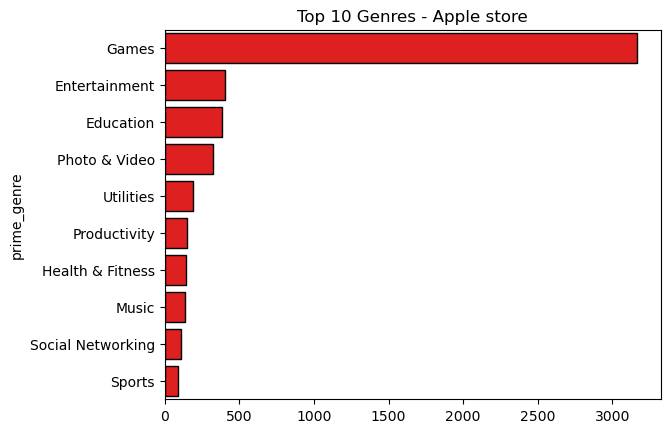

In [108]:
# Top Genres
top_genres = apple_df['prime_genre'].value_counts().head(10)
sns.barplot(x = top_genres.values,y=top_genres.index,color='red',edgecolor='black')
plt.title('Top 10 Genres - Apple store')
plt.show()

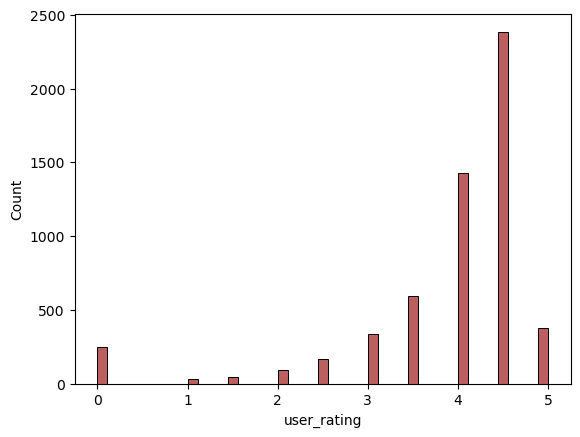

In [112]:
# Rating distribution
sns.histplot(data=apple_df, x='user_rating',color='brown')
plt.show()

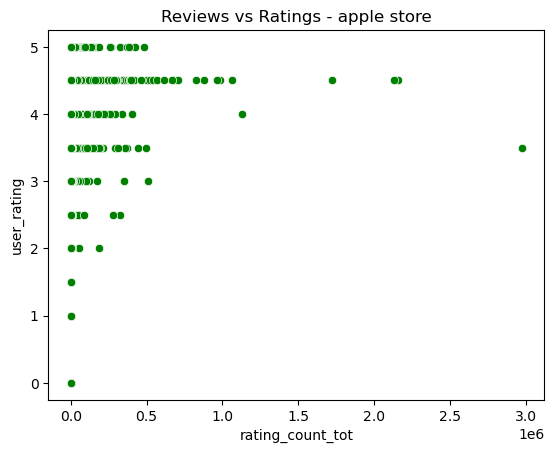

In [114]:
# Reviews vs ratings
sns.scatterplot(data=apple_df,x='rating_count_tot',y='user_rating',color='green')
plt.title('Reviews vs Ratings - apple store')
plt.show()

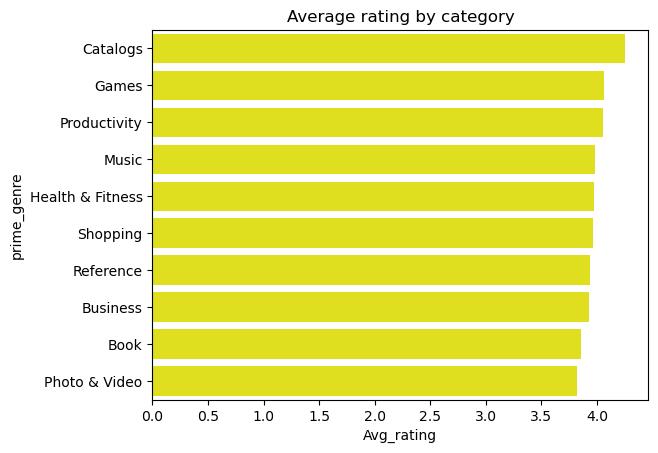

In [119]:
# Average Rating by prime_genre
avg_rating = apple_df.groupby('prime_genre')['user_rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_rating.values, y = avg_rating.index,color = 'yellow')
plt.title('Average rating by category')
plt.xlabel('Avg_rating')
plt.ylabel('prime_genre')
plt.show()